# Validation curve — logistic regression C

Daily notebook — small experiment, fully reproducible (seed pinned below).

Sweeping the regularization strength on breast cancer to see the bias/variance tradeoff directly.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_breast_cancer


## Curve

best C: 0.5995 (val acc 0.9789)


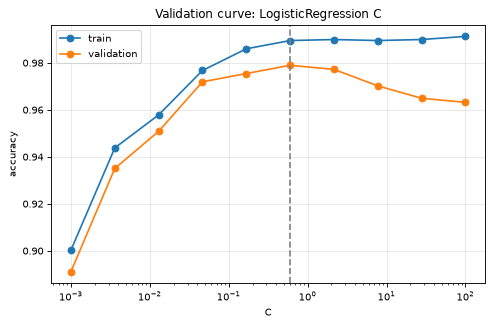

In [ ]:
SEED = 1310
X, y = load_breast_cancer(return_X_y=True)
pipe = Pipeline([("scaler", StandardScaler()),
                 ("model", LogisticRegression(max_iter=5000))])
Cs = np.logspace(-3, 2, 10)
tr, va = validation_curve(pipe, X, y, param_name="model__C", param_range=Cs,
                          cv=5, scoring="accuracy", n_jobs=1)
tr_m, va_m = tr.mean(1), va.mean(1)
best = Cs[int(np.argmax(va_m))]
print(f"best C: {best:.4f} (val acc {va_m.max():.4f})")
fig, ax = plt.subplots()
ax.semilogx(Cs, tr_m, marker="o", label="train")
ax.semilogx(Cs, va_m, marker="o", label="validation")
ax.axvline(best, ls="--", c="gray")
ax.set_xlabel("C"); ax.set_ylabel("accuracy"); ax.legend()
ax.set_title("Validation curve: LogisticRegression C")


## Takeaways

- Wide plateau: C barely matters in the middle decades.
- Tiny C underfits hard — the classic left-side collapse.